**Autor:** Andrés Alejandro Rodríguez Lozano  
**Portafolio:** Portafolio de Andrés Alejandro Rodríguez Lozano

# Capítulo 2 — Crecimiento del portafolio (US$10.000)

Rebalanceo anual vs `SPY`. $$R_{p,t}=\sum_i w_{i,t} R_{i,t},\quad V_t=V_{t-1}(1+R_{p,t})$$


In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT/'src'))
import portfolio_utils as pu
daily = pd.read_csv(ROOT/'data'/'precios_ajustados_diarios.csv', index_col=0, parse_dates=True)
monthly = pu.to_month_end(daily).loc[:'2026-09-30']
bt = pu.backtest_portfolio(monthly, pu.CURRENT_WEIGHTS, start='2016-01-31', end='2026-09-30', rebalance='A')
spy = pu.backtest_portfolio(monthly, {'SPY':1.0}, start='2016-01-31', end='2026-09-30', rebalance='N')
print('Final portafolio:', round(bt['value'].iloc[-1], 2))
print('Final SPY       :', round(spy['value'].iloc[-1], 2))


Final portafolio: 66141.36
Final SPY       : 44481.57


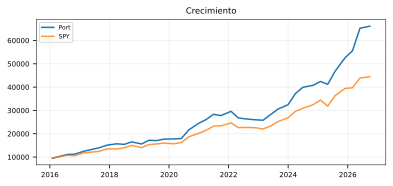

In [1]:
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(bt.index, bt['value'], label='Portafolio', lw=2)
ax.plot(spy.index, spy['value'], label='SPY', lw=2, alpha=0.85)
ax.set_title('Crecimiento US$10.000 · rebalanceo anual · ene-2016 → sep-2026')
ax.set_ylabel('US$'); ax.legend(); plt.tight_layout(); plt.show()


## Conclusiones
1. Los pesos actuales superan a SPY en valor terminal a sep-2026.

## Ejercicios
1. `rebalance='M'`.
2. Sin rebalanceo (`'N'`).
